# 05 - Evaluation & Comparison

Notebook ini menggabungkan hasil ketiga model dan menghasilkan:
1. Tabel perbandingan metrik
2. Grafik perbandingan metrik
3. Loss curve ketiga model
4. Confusion matrix ketiga model
5. Visualisasi contoh deteksi bounding box

## Setup Environment

In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    import os
    PROJECT_ROOT = '/content/drive/MyDrive/malaria-detection'
    os.chdir(PROJECT_ROOT)
else:
    import os
    PROJECT_ROOT = r'D:\malaria-detection'
    os.chdir(PROJECT_ROOT)

print('working directory:', os.getcwd())

working directory: D:\malaria-detection


In [2]:
!pip install -q ultralytics pandas


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import json
import cv2
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: 0


In [4]:
# folder output untuk grafik dan tabel
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'results', 'figures')
TABLES_DIR  = os.path.join(PROJECT_ROOT, 'results', 'tables')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR,  exist_ok=True)

# load summary notebook 01 untuk path dataset
with open(os.path.join(PROJECT_ROOT, 'notebook01_summary.json')) as f:
    summary = json.load(f)

YAML_PATH = summary['yaml_path']
print('yaml path:', YAML_PATH)

yaml path: d:\malaria-detection\malaria.yaml


## Load Hasil Ketiga Model

In [5]:
# load semua json hasil training
result_files = {
    'YOLOv8n'     : os.path.join(PROJECT_ROOT, 'notebook02_results.json'),
    'YOLOv9s'     : os.path.join(PROJECT_ROOT, 'notebook03_results.json'),
    'YOLOv8n+CBAM': os.path.join(PROJECT_ROOT, 'notebook04_results.json'),
}

results = {}
for model_name, path in result_files.items():
    with open(path) as f:
        results[model_name] = json.load(f)
    print(f'{model_name}: loaded dari {path}')

YOLOv8n: loaded dari D:\malaria-detection\notebook02_results.json
YOLOv9s: loaded dari D:\malaria-detection\notebook03_results.json
YOLOv8n+CBAM: loaded dari D:\malaria-detection\notebook04_results.json


## Tabel Perbandingan

In [6]:
# tabel 1: perbandingan akurasi
rows_acc = []
for name, r in results.items():
    rows_acc.append({
        'Model'         : name,
        'mAP@0.5'       : r['map50'],
        'mAP@0.5:0.95'  : r['map50_95'],
        'Precision'     : r['precision'],
        'Recall'        : r['recall'],
        'F1-Score'      : r['f1'],
    })

df_acc = pd.DataFrame(rows_acc).set_index('Model')
print('Tabel 1 - Perbandingan Akurasi:')
print(df_acc.to_string())

# simpan ke csv
df_acc.to_csv(os.path.join(TABLES_DIR, 'comparison_accuracy.csv'))
print('\ndisimpan ke results/tables/comparison_accuracy.csv')

Tabel 1 - Perbandingan Akurasi:
              mAP@0.5  mAP@0.5:0.95  Precision  Recall  F1-Score
Model                                                           
YOLOv8n        0.9613        0.9365     0.9515  0.8934    0.9215
YOLOv9s        0.9617        0.9396     0.9585  0.8910    0.9235
YOLOv8n+CBAM   0.9600        0.9343     0.9381  0.8825    0.9095

disimpan ke results/tables/comparison_accuracy.csv


In [7]:
# tabel 2: perbandingan efisiensi
rows_eff = []
for name, r in results.items():
    rows_eff.append({
        'Model'          : name,
        'FPS'            : r['fps'],
        'Inf. Time (ms)' : r['avg_ms'],
        'Parameters'     : r.get('total_params', r.get('params', '-')),
    })

df_eff = pd.DataFrame(rows_eff).set_index('Model')
print('Tabel 2 - Perbandingan Efisiensi:')
print(df_eff.to_string())

df_eff.to_csv(os.path.join(TABLES_DIR, 'comparison_efficiency.csv'))
print('\ndisimpan ke results/tables/comparison_efficiency.csv')

Tabel 2 - Perbandingan Efisiensi:
                FPS  Inf. Time (ms)  Parameters
Model                                          
YOLOv8n       88.20           11.34     3006038
YOLOv9s       57.53           17.38     7167862
YOLOv8n+CBAM  93.96           10.64     3006038

disimpan ke results/tables/comparison_efficiency.csv


## Grafik Perbandingan Metrik

C:\Users\ASUS\AppData\Local\Temp\ipykernel_33888\2990404332.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_33888\2990404332.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_33888\2990404332.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_33888\2990404332.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.se

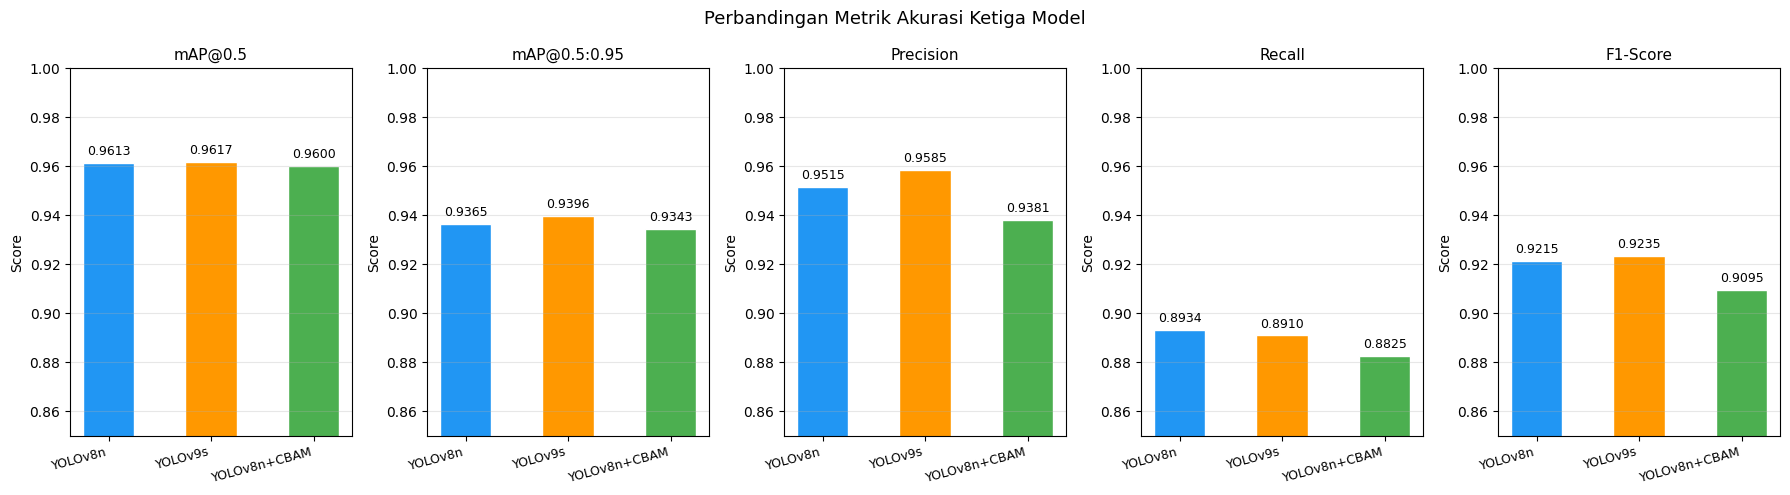

disimpan ke: D:\malaria-detection\results\figures\comparison_accuracy.png


In [8]:
# bar chart perbandingan semua metrik akurasi
metrics_to_plot = ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall', 'F1-Score']
model_names     = list(df_acc.index)
colors          = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 5))

for ax, metric in zip(axes, metrics_to_plot):
    values = df_acc[metric].values
    bars   = ax.bar(model_names, values, color=colors, edgecolor='white', width=0.5)

    # tampilkan nilai di atas bar
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=9
        )

    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0.85, 1.0)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Perbandingan Metrik Akurasi Ketiga Model', fontsize=13)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'comparison_accuracy.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('disimpan ke:', save_path)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_33888\190499841.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(model_names, rotation=15, ha='right')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_33888\190499841.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(model_names, rotation=15, ha='right')


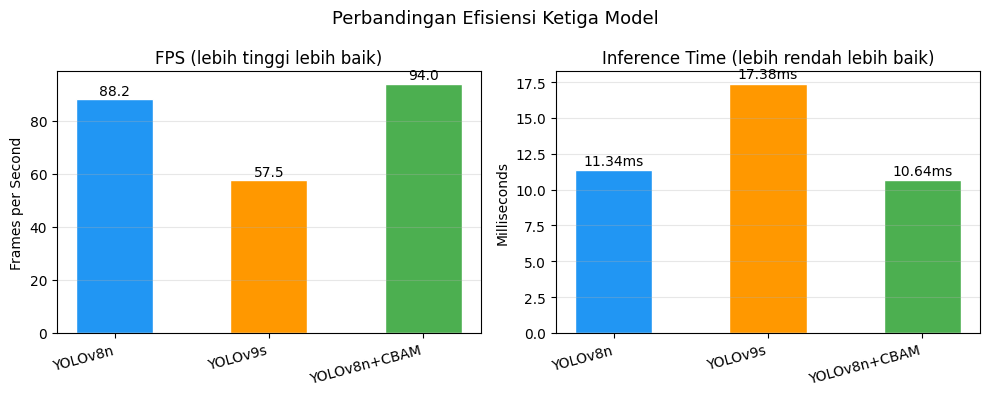

disimpan ke: D:\malaria-detection\results\figures\comparison_efficiency.png


In [9]:
# bar chart perbandingan fps dan inference time
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# fps
fps_vals = df_eff['FPS'].values
bars = axes[0].bar(model_names, fps_vals, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, fps_vals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}',
        ha='center', va='bottom', fontsize=10
    )
axes[0].set_title('FPS (lebih tinggi lebih baik)')
axes[0].set_ylabel('Frames per Second')
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# inference time
ms_vals = df_eff['Inf. Time (ms)'].values
bars = axes[1].bar(model_names, ms_vals, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, ms_vals):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{val:.2f}ms',
        ha='center', va='bottom', fontsize=10
    )
axes[1].set_title('Inference Time (lebih rendah lebih baik)')
axes[1].set_ylabel('Milliseconds')
axes[1].set_xticklabels(model_names, rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Perbandingan Efisiensi Ketiga Model', fontsize=13)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'comparison_efficiency.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('disimpan ke:', save_path)

## Loss Curve Ketiga Model

In [10]:
# baca results.csv dari folder training masing-masing model
run_dirs = {
    'YOLOv8n'     : os.path.join(PROJECT_ROOT, 'runs', 'yolov8n', 'train', 'results.csv'),
    'YOLOv9s'     : os.path.join(PROJECT_ROOT, 'runs', 'yolov9',  'train', 'results.csv'),
    'YOLOv8n+CBAM': os.path.join(PROJECT_ROOT, 'runs', 'yolov8n-cbam', 'train', 'results.csv'),
}

dfs = {}
for name, path in run_dirs.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()  # hapus spasi di nama kolom
        dfs[name] = df
        print(f'{name}: {len(df)} epochs')
    else:
        print(f'{name}: results.csv tidak ditemukan di {path}')

YOLOv8n: 60 epochs
YOLOv9s: 71 epochs
YOLOv8n+CBAM: 85 epochs


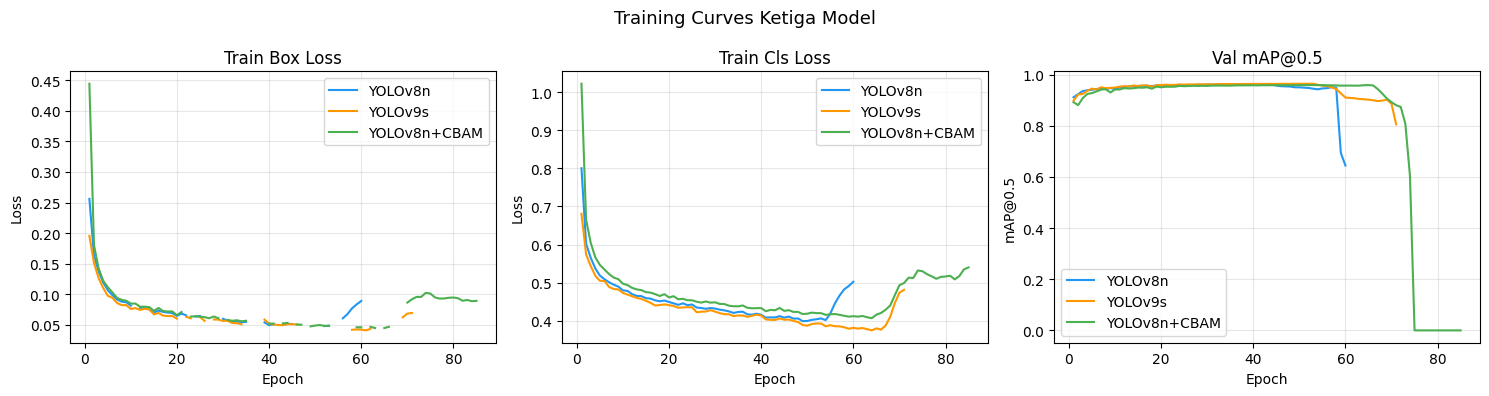

disimpan ke: D:\malaria-detection\results\figures\loss_curves.png


In [11]:
# plot loss curve: box loss, cls loss, val mAP50
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
line_colors = {'YOLOv8n': '#2196F3', 'YOLOv9s': '#FF9800', 'YOLOv8n+CBAM': '#4CAF50'}

for name, df in dfs.items():
    epochs = df['epoch']
    color  = line_colors[name]

    # train box loss
    if 'train/box_loss' in df.columns:
        axes[0].plot(epochs, df['train/box_loss'], label=name, color=color)

    # train cls loss
    if 'train/cls_loss' in df.columns:
        axes[1].plot(epochs, df['train/cls_loss'], label=name, color=color)

    # val mAP50
    if 'metrics/mAP50(B)' in df.columns:
        axes[2].plot(epochs, df['metrics/mAP50(B)'], label=name, color=color)

axes[0].set_title('Train Box Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Train Cls Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].set_title('Val mAP@0.5')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('mAP@0.5')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Training Curves Ketiga Model', fontsize=13)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'loss_curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('disimpan ke:', save_path)

## Confusion Matrix Ketiga Model

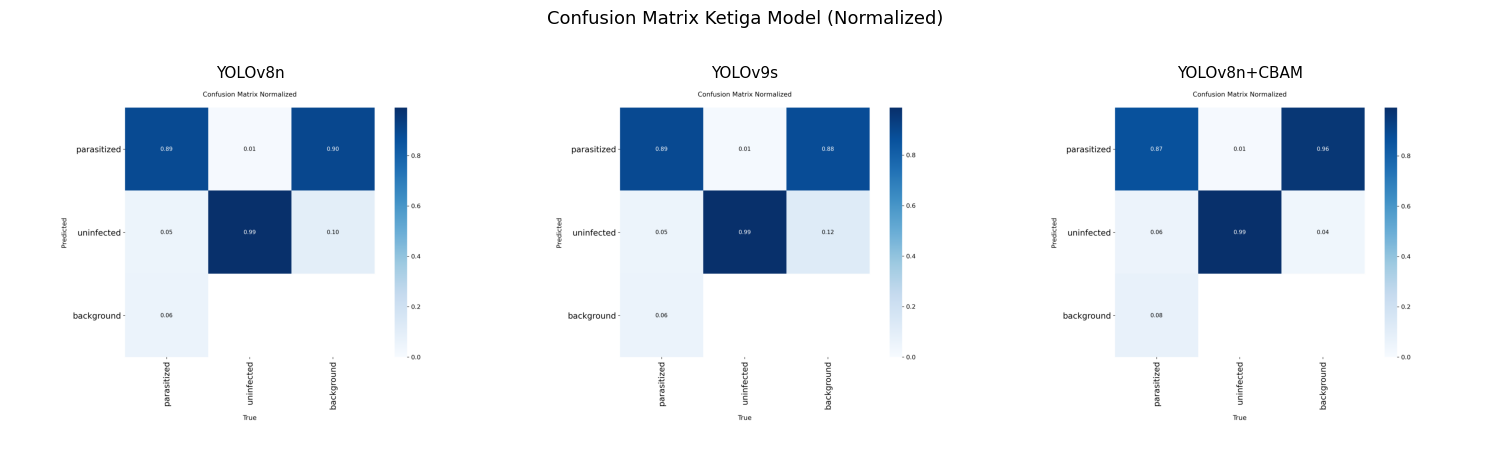

disimpan ke: D:\malaria-detection\results\figures\confusion_matrix_all.png


In [12]:
# confusion matrix sudah di-generate otomatis oleh ultralytics saat val
# ambil dari folder training masing-masing model
cm_paths = {
    'YOLOv8n'     : os.path.join(PROJECT_ROOT, 'runs', 'yolov8n',     'train', 'confusion_matrix_normalized.png'),
    'YOLOv9s'     : os.path.join(PROJECT_ROOT, 'runs', 'yolov9',      'train', 'confusion_matrix_normalized.png'),
    'YOLOv8n+CBAM': os.path.join(PROJECT_ROOT, 'runs', 'yolov8n-cbam','train', 'confusion_matrix_normalized.png'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, path) in zip(axes, cm_paths.items()):
    if os.path.exists(path):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(name, fontsize=11)
        ax.axis('off')
    else:
        ax.text(0.5, 0.5, f'{name}\ntidak ditemukan',
                ha='center', va='center', fontsize=10)
        ax.axis('off')

plt.suptitle('Confusion Matrix Ketiga Model (Normalized)', fontsize=13)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'confusion_matrix_all.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('disimpan ke:', save_path)

## Visualisasi Contoh Deteksi Bounding Box

In [13]:
# load ketiga model
models = {
    'YOLOv8n'     : YOLO(results['YOLOv8n']['best_weights']),
    'YOLOv9s'     : YOLO(results['YOLOv9s']['best_weights']),
    'YOLOv8n+CBAM': YOLO(results['YOLOv8n+CBAM']['best_weights']),
}

print('semua model loaded')

semua model loaded


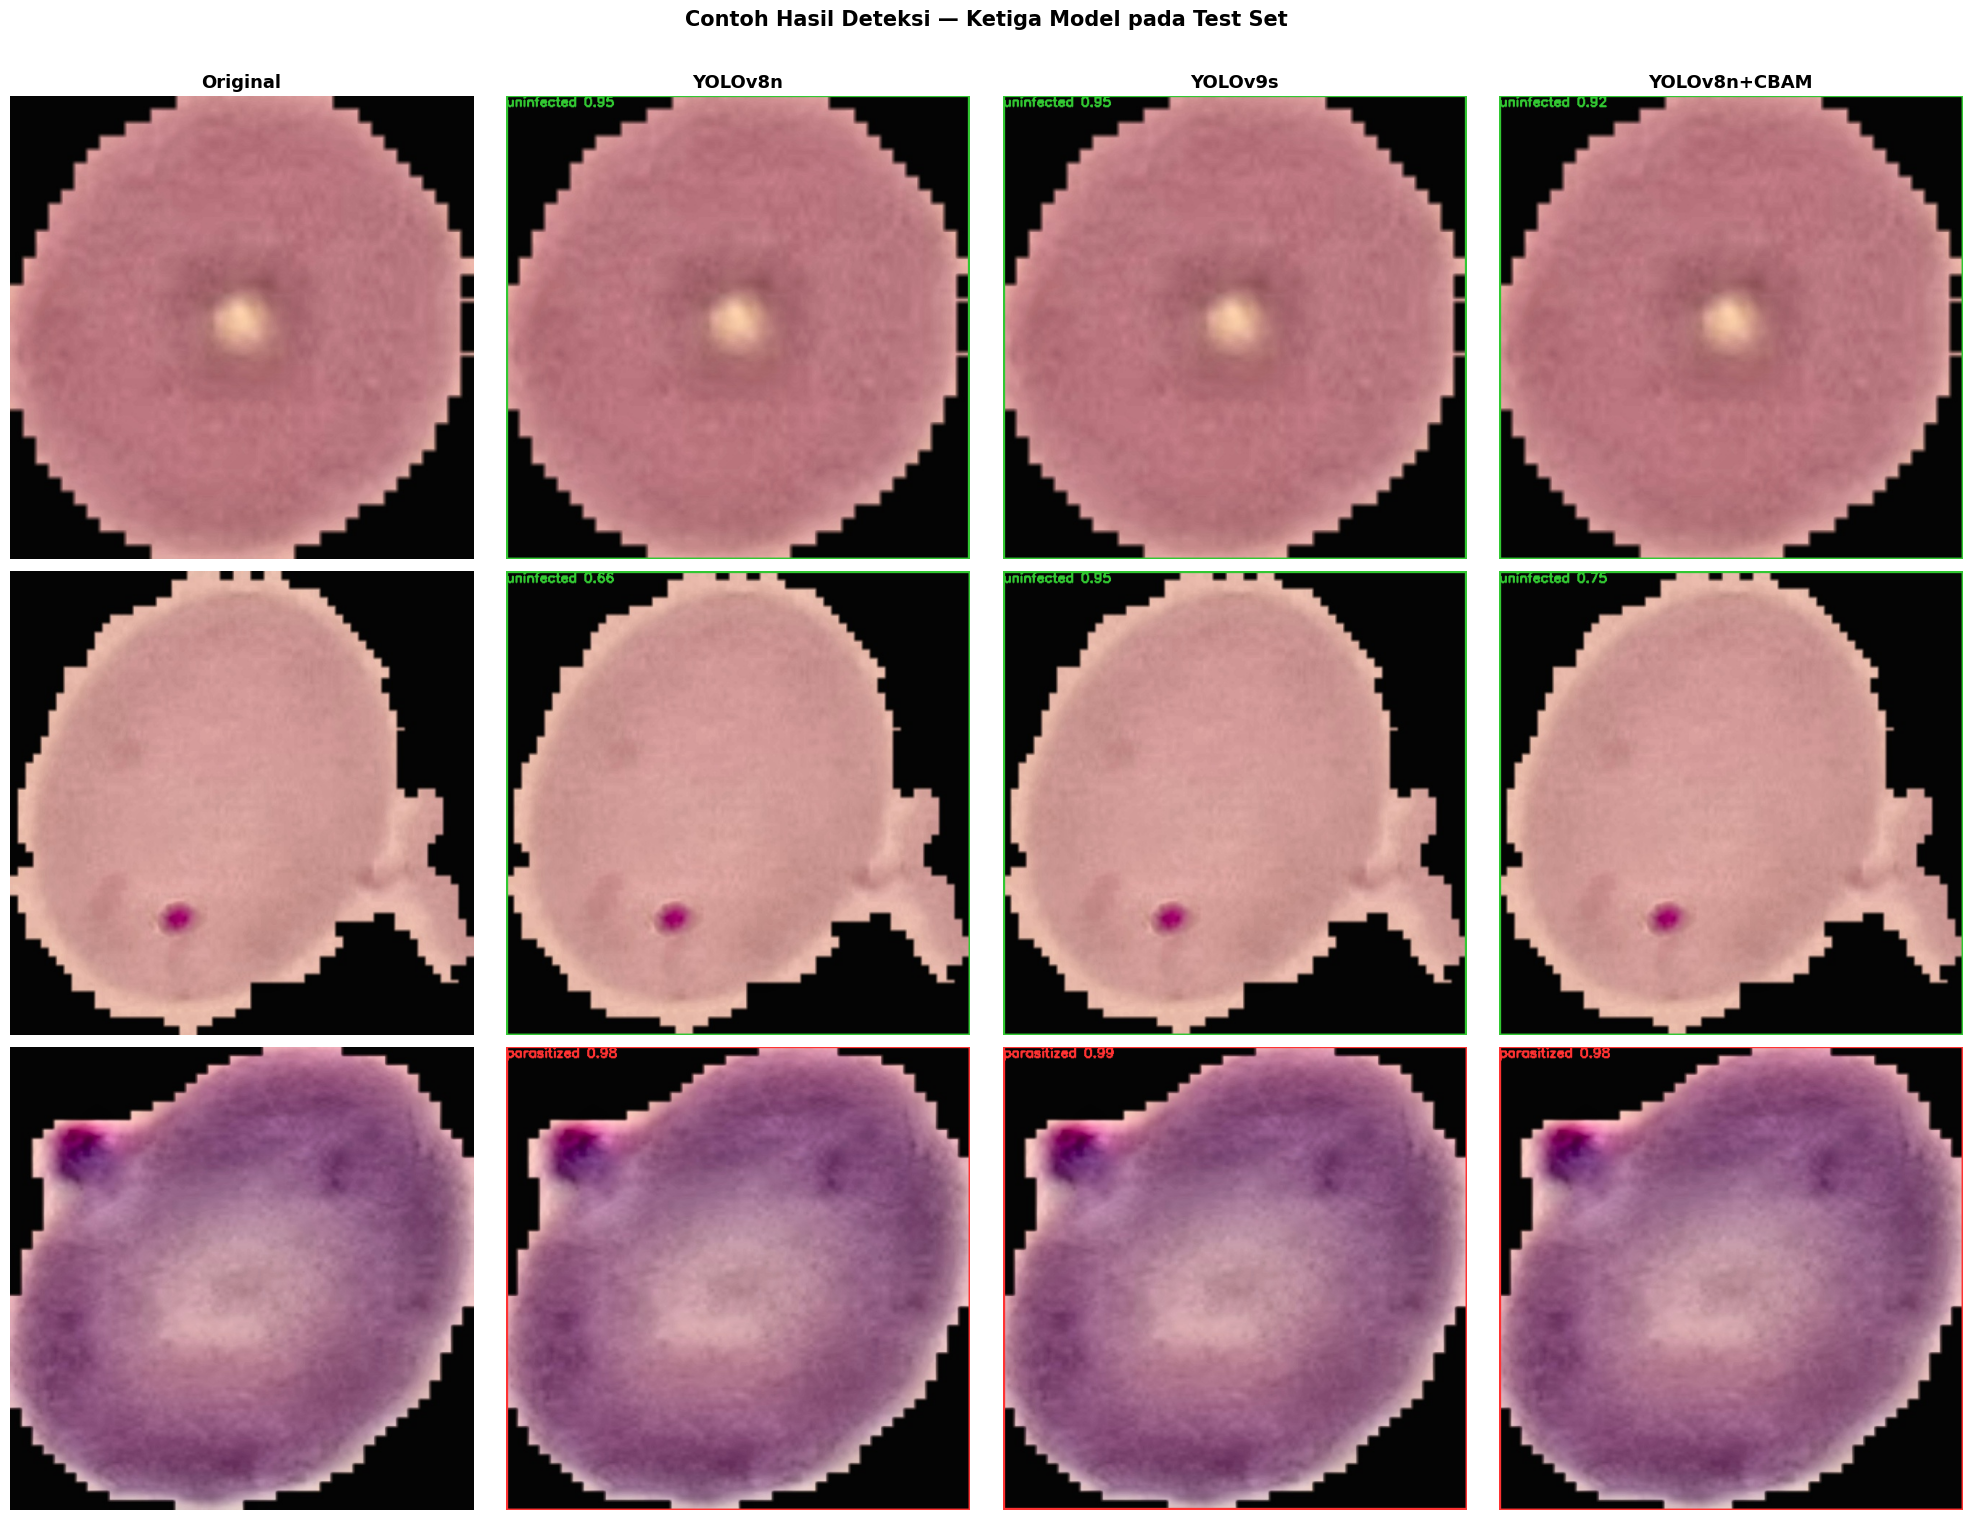

disimpan ke: D:\malaria-detection\results\figures\detection_samples.png


In [17]:
# ambil 3 gambar sample dari test set secara acak
test_imgs = list(Path(summary['PATHS']['img_test']).glob('*.jpg'))
random.seed(42)
sample_imgs = random.sample(test_imgs, 3)

class_names  = {0: 'parasitized', 1: 'uninfected'}
class_colors = {0: (255, 50, 50), 1: (50, 200, 50)}

fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for row, img_path in enumerate(sample_imgs):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_bgr.shape[:2]

    # kolom 0: gambar original
    axes[row][0].imshow(img_rgb)
    axes[row][0].set_title('Original', fontsize=13, fontweight='bold') if row == 0 else None
    axes[row][0].axis('off')

    # kolom 1-3: hasil prediksi tiap model
    for col, (model_name, model) in enumerate(models.items(), start=1):
        pred = model.predict(img_bgr, verbose=False, device=DEVICE, conf=0.5, iou=0.5)[0]
        vis  = img_rgb.copy()

        for box in pred.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            cls  = int(box.cls[0])
            conf = float(box.conf[0])
            color = class_colors.get(cls, (100, 100, 255))

            # bounding box lebih tebal
            cv2.rectangle(vis, (x1, y1), (x2, y2), color, 3)

            # label lebih besar
            label = f"{class_names.get(cls, str(cls))} {conf:.2f}"
            cv2.putText(vis, label, (x1, max(y1 - 8, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        axes[row][col].imshow(vis)
        axes[row][col].set_title(model_name, fontsize=13, fontweight='bold') if row == 0 else None
        axes[row][col].axis('off')

plt.suptitle('Contoh Hasil Deteksi — Ketiga Model pada Test Set',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'detection_samples.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('disimpan ke:', save_path)

## Ringkasan Akhir

In [18]:
# cetak ringkasan hasil untuk artikel
print('=' * 60)
print('RINGKASAN HASIL — SIAP UNTUK ARTIKEL')
print('=' * 60)
print()
print('Tabel 1 - Perbandingan Akurasi:')
print(df_acc.to_string())
print()
print('Tabel 2 - Perbandingan Efisiensi:')
print(df_eff.to_string())
print()
print('Output yang dihasilkan:')
for f in os.listdir(FIGURES_DIR):
    print(f'  results/figures/{f}')
for f in os.listdir(TABLES_DIR):
    print(f'  results/tables/{f}')

RINGKASAN HASIL — SIAP UNTUK ARTIKEL

Tabel 1 - Perbandingan Akurasi:
              mAP@0.5  mAP@0.5:0.95  Precision  Recall  F1-Score
Model                                                           
YOLOv8n        0.9613        0.9365     0.9515  0.8934    0.9215
YOLOv9s        0.9617        0.9396     0.9585  0.8910    0.9235
YOLOv8n+CBAM   0.9600        0.9343     0.9381  0.8825    0.9095

Tabel 2 - Perbandingan Efisiensi:
                FPS  Inf. Time (ms)  Parameters
Model                                          
YOLOv8n       88.20           11.34     3006038
YOLOv9s       57.53           17.38     7167862
YOLOv8n+CBAM  93.96           10.64     3006038

Output yang dihasilkan:
  results/figures/clahe_comparison.png
  results/figures/class_distribution.png
  results/figures/comparison_accuracy.png
  results/figures/comparison_efficiency.png
  results/figures/confusion_matrix_all.png
  results/figures/detection_samples.png
  results/figures/loss_curves.png
  results/figures/samp

In [19]:
print('notebook 05 selesai')
print('semua output tersimpan di folder results/')
print()
print('langkah selanjutnya: penulisan artikel (Minggu 12-13)')

notebook 05 selesai
semua output tersimpan di folder results/

langkah selanjutnya: penulisan artikel (Minggu 12-13)
